# 11_deeponet_train.ipynb

DeepONet для задачи **sensor -> speed map** на `usct_dataset_v2`.

В этом ноутбуке:
- используется тот же residual-протокол, что и в CNN baseline;
- данные берутся из `train / val / test`;
- считается `M_hom` для однородной среды;
- обучается DeepONet:
  - **branch net** кодирует measurement tensor,
  - **trunk net** кодирует координаты пикселей,
  - выход даёт поле `c(x, y)` на всей сетке;
- сохраняется лучший checkpoint;
- считаются `RMSE / relative L2 / PSNR / SSIM`.

## 0. Важно
`M_hom` считается через `j-Wave`, но для устойчивости JAX здесь запускается на **CPU**.
Сама DeepONet-модель обучается в **PyTorch** и использует GPU, если он доступен.

In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ.pop("LD_LIBRARY_PATH", None)

'/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/local/cuda/lib64'

In [2]:
from pathlib import Path
import json
import math
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu130
cuda available: True
device name: NVIDIA GeForce RTX 5090


In [3]:
CFG = {
    "dataset_root": "/workspace/usct_dataset_v2",
    "run_name": "deeponet_v1",
    "batch_size": 8,
    "epochs": 120,
    "patience": 20,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "num_workers": 0,
    "mask_half_width": 2,
    "use_residual": True,
    "branch_width": 128,
    "trunk_width": 128,
    "trunk_hidden": 128,
    "num_fourier_features": 16,
    "dropout": 0.0,
}
CFG

{'dataset_root': '/workspace/usct_dataset_v2',
 'run_name': 'deeponet_v1',
 'batch_size': 8,
 'epochs': 120,
 'patience': 20,
 'lr': 0.001,
 'weight_decay': 1e-05,
 'num_workers': 0,
 'mask_half_width': 2,
 'use_residual': True,
 'branch_width': 128,
 'trunk_width': 128,
 'trunk_hidden': 128,
 'num_fourier_features': 16,
 'dropout': 0.0}

In [4]:
OUT_ROOT = Path(CFG["dataset_root"])
TRAIN_DIR = OUT_ROOT / "train"
VAL_DIR = OUT_ROOT / "val"
TEST_DIR = OUT_ROOT / "test"

assert TRAIN_DIR.exists(), TRAIN_DIR
assert VAL_DIR.exists(), VAL_DIR
assert TEST_DIR.exists(), TEST_DIR

train_files = sorted(TRAIN_DIR.glob("*.npz"))
val_files = sorted(VAL_DIR.glob("*.npz"))
test_files = sorted(TEST_DIR.glob("*.npz"))

print("train:", len(train_files))
print("val:", len(val_files))
print("test:", len(test_files))
assert len(train_files) > 0 and len(val_files) > 0 and len(test_files) > 0

train: 6200
val: 1000
test: 800


In [5]:
sample0 = np.load(train_files[0])

S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

receiver_y = np.array(sample0["receiver_y"].astype(np.int32))
receiver_x = np.array(sample0["receiver_x"].astype(np.int32))
source_ring_idx_full = np.array(sample0["source_ring_idx"].astype(np.int32))

all_c_values = []
for p in train_files:
    c = np.load(p)["c"].astype(np.float32)
    all_c_values.append(c)
all_c_values = np.stack(all_c_values, axis=0)

stats = {
    "c_min": float(all_c_values.min()),
    "c_max": float(all_c_values.max()),
}
print("S, R:", S, R)
print("H, W:", H, W)
print("dx:", dx)
print("freq_hz:", freq_hz)
print("stats:", stats)

S, R: 16 256
H, W: 192 192
dx: (np.float32(0.00075), np.float32(0.00075))
freq_hz: 500000.0
stats: {'c_min': 1404.1473388671875, 'c_max': 1598.34423828125}


## 1. `M_hom` через j-Wave

In [6]:
import jax
import jax.numpy as jnp
from jax import jit

from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

print("jax version:", jax.__version__)
print("jax devices:", jax.devices())

jax version: 0.4.38
jax devices: [CpuDevice(id=0)]


In [7]:
domain = Domain((H, W), dx)
omega = 2 * np.pi * freq_hz

def gaussian_source(H, W, y0, x0, sigma=1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    g = g / g.sum()
    return g.astype(np.float32)

full_source_fields = []
for ridx in source_ring_idx_full:
    y0 = int(receiver_y[ridx])
    x0 = int(receiver_x[ridx])
    src_np = gaussian_source(H, W, y0, x0, sigma=1.8)
    full_source_fields.append(jnp.array(src_np, dtype=jnp.complex64))
full_source_fields = tuple(full_source_fields)

def make_medium(c_map):
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    medium = Medium(
        domain=domain,
        sound_speed=sound_speed,
        density=1000.0,
        pml_size=16,
    )
    return medium

def forward_measurements_full(c_map):
    medium = make_medium(c_map)
    ms = []
    for i in range(len(full_source_fields)):
        src = FourierSeries(jnp.expand_dims(full_source_fields[i], -1), domain)
        field = helmholtz_solver(medium, omega, src * omega)
        u = field.params[..., 0]
        ms.append(u[receiver_y, receiver_x])
    return jnp.stack(ms, axis=0)

forward_measurements_full_jit = jit(forward_measurements_full)

/tmp/ipykernel_7890/2997561755.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


M_hom_complex: (16, 256) complex64
time: 25.896543502807617 sec


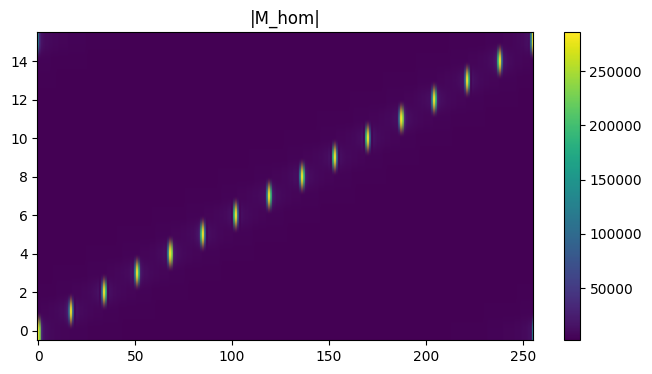

In [8]:
c_hom = jnp.full((H, W), 1500.0, dtype=jnp.float32)

t0 = time.time()
M_hom_complex = forward_measurements_full_jit(c_hom)
M_hom_complex.block_until_ready()
t1 = time.time()

M_hom_complex = np.array(M_hom_complex)

print("M_hom_complex:", M_hom_complex.shape, M_hom_complex.dtype)
print("time:", t1 - t0, "sec")

plt.figure(figsize=(8, 4))
plt.imshow(np.abs(M_hom_complex), aspect="auto", origin="lower")
plt.title("|M_hom|")
plt.colorbar()
plt.show()

## 2. Dataset

In [9]:
def mask_self_receivers(M, source_ring_idx, half_width=2):
    M = M.copy()
    S_local, R_local = M.shape
    for s in range(S_local):
        ridx = int(source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % R_local
            M[s, rr] = 0.0 + 0.0j
    return M

class USCTDeepONetDataset(Dataset):
    def __init__(self, paths, c_min, c_max, M_hom_complex, use_residual=True, mask_half_width=2):
        self.paths = list(paths)
        self.c_min = float(c_min)
        self.c_max = float(c_max)
        self.c_range = max(self.c_max - self.c_min, 1e-8)
        self.M_hom_complex = M_hom_complex
        self.use_residual = bool(use_residual)
        self.mask_half_width = int(mask_half_width)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        d = np.load(self.paths[idx])

        x_raw = d["x"].astype(np.float32)
        c = d["c"].astype(np.float32)
        source_ring_idx = d["source_ring_idx"].astype(np.int64)

        M = x_raw[0] + 1j * x_raw[1]

        if self.use_residual:
            M = M - self.M_hom_complex

        if self.mask_half_width > 0:
            M = mask_self_receivers(M, source_ring_idx, half_width=self.mask_half_width)

        x_tensor = np.stack([M.real, M.imag], axis=0).astype(np.float32)

        x_scale = float(np.percentile(np.abs(x_tensor), 99.5))
        if x_scale < 1e-8:
            x_scale = 1.0
        x_tensor = x_tensor / x_scale

        c_norm = (c - self.c_min) / self.c_range

        return (
            torch.from_numpy(x_tensor),
            torch.from_numpy(c_norm).unsqueeze(0),
            {
                "path": str(self.paths[idx]),
                "x_scale": x_scale,
            },
        )

In [10]:
ds_train = USCTDeepONetDataset(
    train_files,
    stats["c_min"],
    stats["c_max"],
    M_hom_complex=M_hom_complex,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)

ds_val = USCTDeepONetDataset(
    val_files,
    stats["c_min"],
    stats["c_max"],
    M_hom_complex=M_hom_complex,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)

ds_test = USCTDeepONetDataset(
    test_files,
    stats["c_min"],
    stats["c_max"],
    M_hom_complex=M_hom_complex,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)

x0, c0, meta0 = ds_train[0]
print("x0:", x0.shape, x0.dtype)
print("c0:", c0.shape, c0.dtype)
print(meta0)

x0: torch.Size([2, 16, 256]) torch.float32
c0: torch.Size([1, 192, 192]) torch.float32
{'path': '/workspace/usct_dataset_v2/train/sample_00000.npz', 'x_scale': 5201.7001953125}


## 3. Координатная сетка trunk-сети

In [11]:
yy = np.linspace(-1.0, 1.0, H, dtype=np.float32)
xx = np.linspace(-1.0, 1.0, W, dtype=np.float32)
grid_y, grid_x = np.meshgrid(yy, xx, indexing="ij")
coords = np.stack([grid_y, grid_x], axis=-1).reshape(-1, 2)
coords_t = torch.from_numpy(coords)

print("coords_t:", coords_t.shape)

coords_t: torch.Size([36864, 2])


## 4. DeepONet

In [12]:
class BranchEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(1, 32),
            nn.GELU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 64),
            nn.GELU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 128),
            nn.GELU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 128),
            nn.GELU(),
            nn.Flatten(),
            nn.Linear(128 * 2 * 32, 256),
            nn.GELU(),
            nn.Linear(256, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class TrunkNet(nn.Module):
    def __init__(self, width=128, hidden=128, num_fourier_features=16):
        super().__init__()
        self.num_fourier_features = int(num_fourier_features)

        if self.num_fourier_features > 0:
            freq = 2.0 ** torch.arange(self.num_fourier_features, dtype=torch.float32) * math.pi
            self.register_buffer("freq", freq, persistent=False)
            in_dim = 2 + 4 * self.num_fourier_features
        else:
            self.register_buffer("freq", torch.empty(0), persistent=False)
            in_dim = 2

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, width),
        )

    def encode_coords(self, coords):
        if self.num_fourier_features == 0:
            return coords

        y = coords[:, 0:1]
        x = coords[:, 1:2]

        y_proj = y * self.freq[None, :]
        x_proj = x * self.freq[None, :]

        feats = [
            coords,
            torch.sin(y_proj),
            torch.cos(y_proj),
            torch.sin(x_proj),
            torch.cos(x_proj),
        ]
        return torch.cat(feats, dim=1)

    def forward(self, coords):
        return self.net(self.encode_coords(coords))

class DeepONet2D(nn.Module):
    def __init__(self, branch_width=128, trunk_width=128, trunk_hidden=128, num_fourier_features=16):
        super().__init__()
        self.branch = BranchEncoder(out_dim=branch_width)
        self.trunk = TrunkNet(
            width=trunk_width,
            hidden=trunk_hidden,
            num_fourier_features=num_fourier_features,
        )
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x, coords):
        b = self.branch(x)
        t = self.trunk(coords)
        out = torch.matmul(b, t.t()) + self.bias
        out = out.view(x.shape[0], 1, H, W)
        return out

## 5. Метрики и train/eval helpers

In [13]:
def denorm_c(c_norm, c_min, c_max):
    return c_norm * (c_max - c_min) + c_min

def mse(a, b):
    return float(np.mean((a - b) ** 2))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def relative_l2(a, b):
    num = np.linalg.norm(a - b)
    den = np.linalg.norm(b) + 1e-8
    return float(num / den)

def psnr_from_mse(mse_value, data_range):
    if mse_value <= 1e-12:
        return float("inf")
    return float(20 * np.log10(data_range) - 10 * np.log10(mse_value))

try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
    ssim_fn = None

def compute_metrics(pred, target, data_range):
    out = {
        "mse": mse(pred, target),
        "rmse": rmse(pred, target),
        "relative_l2": relative_l2(pred, target),
        "psnr": psnr_from_mse(mse(pred, target), data_range),
    }
    if HAS_SKIMAGE:
        out["ssim"] = float(ssim_fn(pred, target, data_range=data_range))
    return out

def train_one_epoch(model, loader, optimizer, criterion, device, coords_device, scaler=None):
    model.train()
    total_loss = 0.0

    for x, c, _ in loader:
        x = x.to(device, non_blocking=True)
        c = c.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if scaler is None:
            pred = model(x, coords_device)
            loss = criterion(pred, c)
            loss.backward()
            optimizer.step()
        else:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                pred = model(x, coords_device)
                loss = criterion(pred, c)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        total_loss += float(loss.item()) * x.shape[0]

    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_loss(model, loader, criterion, device, coords_device):
    model.eval()
    total_loss = 0.0

    for x, c, _ in loader:
        x = x.to(device, non_blocking=True)
        c = c.to(device, non_blocking=True)
        pred = model(x, coords_device)
        loss = criterion(pred, c)
        total_loss += float(loss.item()) * x.shape[0]

    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_dataset(model, dataset, device, coords_device, c_min, c_max):
    model.eval()
    metrics_list = []
    data_range = float(c_max - c_min)

    for idx in range(len(dataset)):
        x, c, meta = dataset[idx]
        pred = model(x.unsqueeze(0).to(device), coords_device)[0, 0].cpu().numpy()
        target = c[0].numpy()

        pred_phys = denorm_c(pred, c_min, c_max)
        target_phys = denorm_c(target, c_min, c_max)

        m = compute_metrics(pred_phys, target_phys, data_range=data_range)
        m["index"] = idx
        m["path"] = meta["path"]
        metrics_list.append(m)

    return metrics_list

def summarize_metrics(metrics_list):
    summary = {}
    for key in metrics_list[0].keys():
        if key in ("index", "path"):
            continue
        vals = [m[key] for m in metrics_list]
        summary[f"{key}_mean"] = float(np.mean(vals))
        summary[f"{key}_std"] = float(np.std(vals))
    return summary

## 6. Dataloaders

In [14]:
train_loader = DataLoader(
    ds_train,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    ds_val,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=torch.cuda.is_available(),
)

print("num train batches:", len(train_loader))
print("num val batches:", len(val_loader))

num train batches: 775
num val batches: 125


## 7. Обучение

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
coords_device = coords_t.to(device)

model = DeepONet2D(
    branch_width=CFG["branch_width"],
    trunk_width=CFG["trunk_width"],
    trunk_hidden=CFG["trunk_hidden"],
    num_fourier_features=CFG["num_fourier_features"],
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"],
)

criterion = nn.MSELoss()

use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda") if use_amp else None

RUN_DIR = Path("/workspace/reference_points") / CFG["run_name"]
RUN_DIR.mkdir(parents=True, exist_ok=True)

best_val = float("inf")
best_epoch = -1
best_ckpt_path = RUN_DIR / "deeponet_best.pt"

train_history = []
val_history = []
epochs_no_improve = 0

t0 = time.time()

for epoch in range(1, CFG["epochs"] + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, coords_device, scaler=scaler)
    val_loss = eval_loss(model, val_loader, criterion, device, coords_device)

    train_history.append(train_loss)
    val_history.append(val_loss)

    print(f"epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    if val_loss < best_val:
        best_val = val_loss
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "stats": stats,
                "config": CFG,
                "best_epoch": best_epoch,
                "best_val": best_val,
            },
            best_ckpt_path,
        )
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= CFG["patience"]:
        print("early stopping")
        break

t1 = time.time()
print("training time sec:", t1 - t0)
print("best_epoch:", best_epoch)
print("best_val:", best_val)

epoch 001 | train_loss=0.256964 | val_loss=0.008872
epoch 002 | train_loss=0.008437 | val_loss=0.007894
epoch 003 | train_loss=0.008075 | val_loss=0.007719
epoch 004 | train_loss=0.007892 | val_loss=0.007651
epoch 005 | train_loss=0.007747 | val_loss=0.007667
epoch 006 | train_loss=0.007629 | val_loss=0.007479
epoch 007 | train_loss=0.007330 | val_loss=0.007036
epoch 008 | train_loss=0.007112 | val_loss=0.006656
epoch 009 | train_loss=0.006850 | val_loss=0.006616
epoch 010 | train_loss=0.006683 | val_loss=0.006358
epoch 011 | train_loss=0.006477 | val_loss=0.006186
epoch 012 | train_loss=0.006344 | val_loss=0.006107
epoch 013 | train_loss=0.006133 | val_loss=0.005878
epoch 014 | train_loss=0.005954 | val_loss=0.005937
epoch 015 | train_loss=0.005777 | val_loss=0.005602
epoch 016 | train_loss=0.005616 | val_loss=0.005450
epoch 017 | train_loss=0.005442 | val_loss=0.005218
epoch 018 | train_loss=0.005321 | val_loss=0.005074
epoch 019 | train_loss=0.005175 | val_loss=0.005017
epoch 020 | 

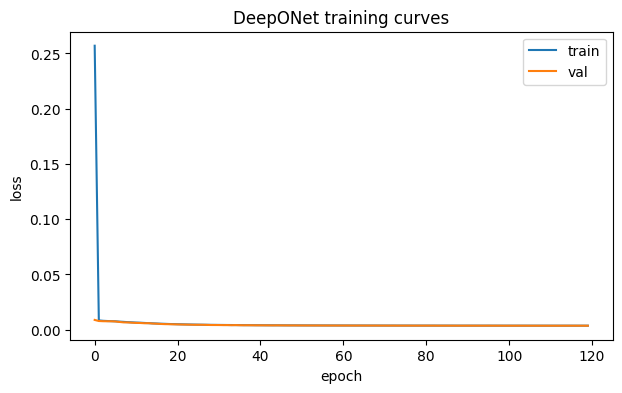

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(train_history, label="train")
plt.plot(val_history, label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("DeepONet training curves")
plt.legend()
plt.show()

## 8. Загрузка лучшего checkpoint и evaluation

In [17]:
best_ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(best_ckpt["model_state_dict"])
model.eval()

train_metrics = evaluate_dataset(model, ds_train, device, coords_device, stats["c_min"], stats["c_max"])
val_metrics = evaluate_dataset(model, ds_val, device, coords_device, stats["c_min"], stats["c_max"])
test_metrics = evaluate_dataset(model, ds_test, device, coords_device, stats["c_min"], stats["c_max"])

train_summary = summarize_metrics(train_metrics)
val_summary = summarize_metrics(val_metrics)
test_summary = summarize_metrics(test_metrics)

print("TRAIN SUMMARY")
print(json.dumps(train_summary, ensure_ascii=False, indent=2))

print("\nVAL SUMMARY")
print(json.dumps(val_summary, ensure_ascii=False, indent=2))

print("\nTEST SUMMARY")
print(json.dumps(test_summary, ensure_ascii=False, indent=2))

TRAIN SUMMARY
{
  "mse_mean": 137.0746700176116,
  "mse_std": 65.31102628907175,
  "rmse_mean": 11.364252753949934,
  "rmse_std": 2.815746674649419,
  "relative_l2_mean": 0.007615593330814473,
  "relative_l2_std": 0.0018844044880476068,
  "psnr_mean": 24.934352800706247,
  "psnr_std": 2.2410417727752487
}

VAL SUMMARY
{
  "mse_mean": 136.79385748672485,
  "mse_std": 64.28963138703071,
  "rmse_mean": 11.366987645149232,
  "rmse_std": 2.7541694910678673,
  "relative_l2_mean": 0.007617523293010891,
  "relative_l2_std": 0.001840294190770329,
  "psnr_mean": 24.917349471925167,
  "psnr_std": 2.1755389931980824
}

TEST SUMMARY
{
  "mse_mean": 212.35678208351135,
  "mse_std": 114.50250076712844,
  "rmse_mean": 14.017671887874604,
  "rmse_std": 3.9826696923497007,
  "relative_l2_mean": 0.009394530308782123,
  "relative_l2_std": 0.002665916719046646,
  "psnr_mean": 23.20472241947531,
  "psnr_std": 2.5958844980920834
}


## 9. Визуализация prediction

In [18]:
@torch.no_grad()
def show_prediction(model, dataset, idx, device, coords_device, c_min, c_max):
    x, c, meta = dataset[idx]
    pred = model(x.unsqueeze(0).to(device), coords_device)[0, 0].cpu().numpy()
    target = c[0].numpy()

    pred_phys = denorm_c(pred, c_min, c_max)
    target_phys = denorm_c(target, c_min, c_max)
    err = np.abs(pred_phys - target_phys)

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))

    im0 = ax[0].imshow(target_phys, origin="lower")
    ax[0].set_title(f"target | idx={idx}")
    plt.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(pred_phys, origin="lower")
    ax[1].set_title("DeepONet prediction")
    plt.colorbar(im1, ax=ax[1])

    im2 = ax[2].imshow(err, origin="lower")
    ax[2].set_title("|pred-target|")
    plt.colorbar(im2, ax=ax[2])

    plt.tight_layout()
    plt.show()
    print(meta["path"])

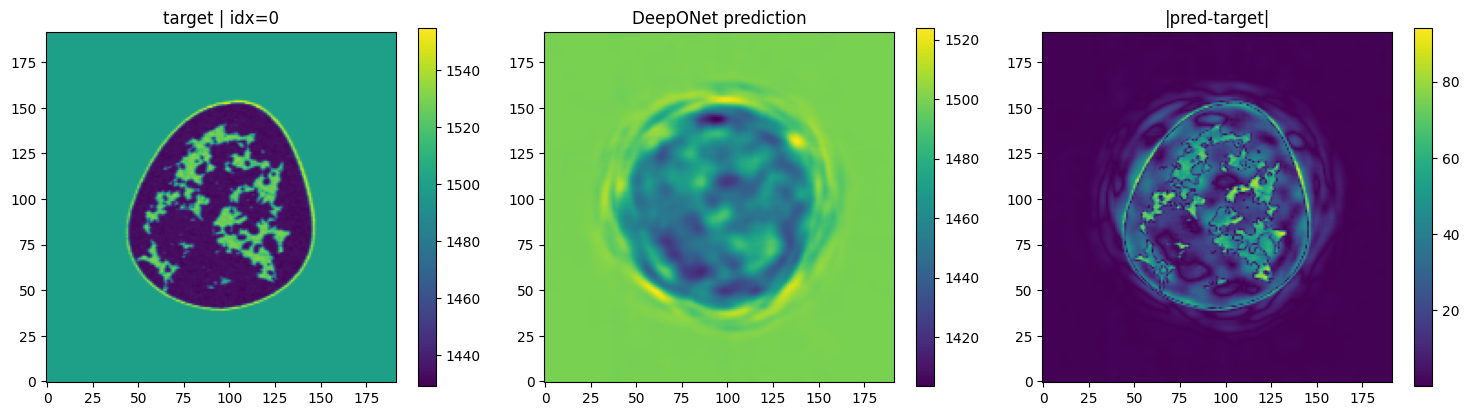

/workspace/usct_dataset_v2/test/sample_00000.npz


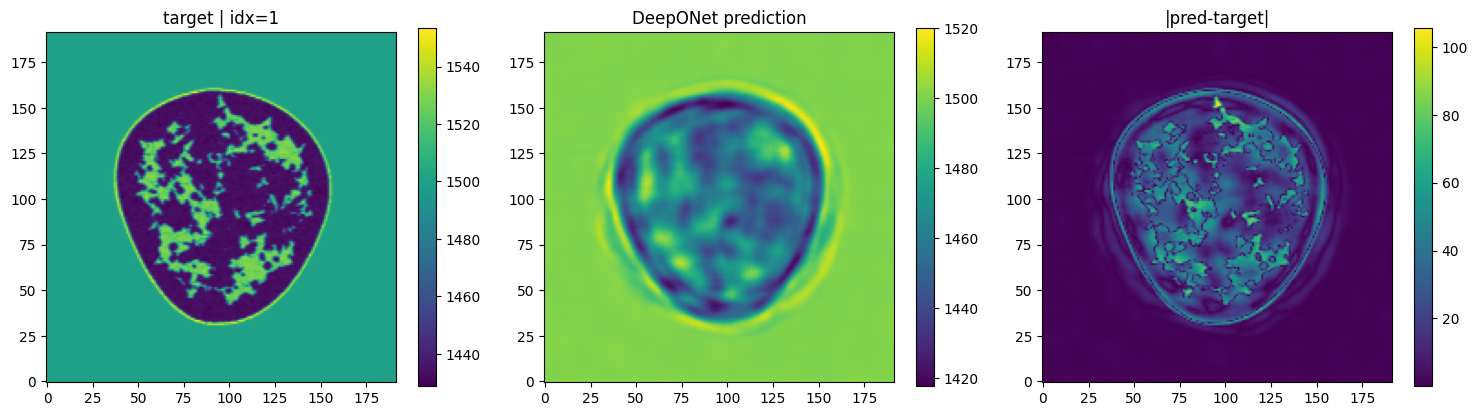

/workspace/usct_dataset_v2/test/sample_00001.npz


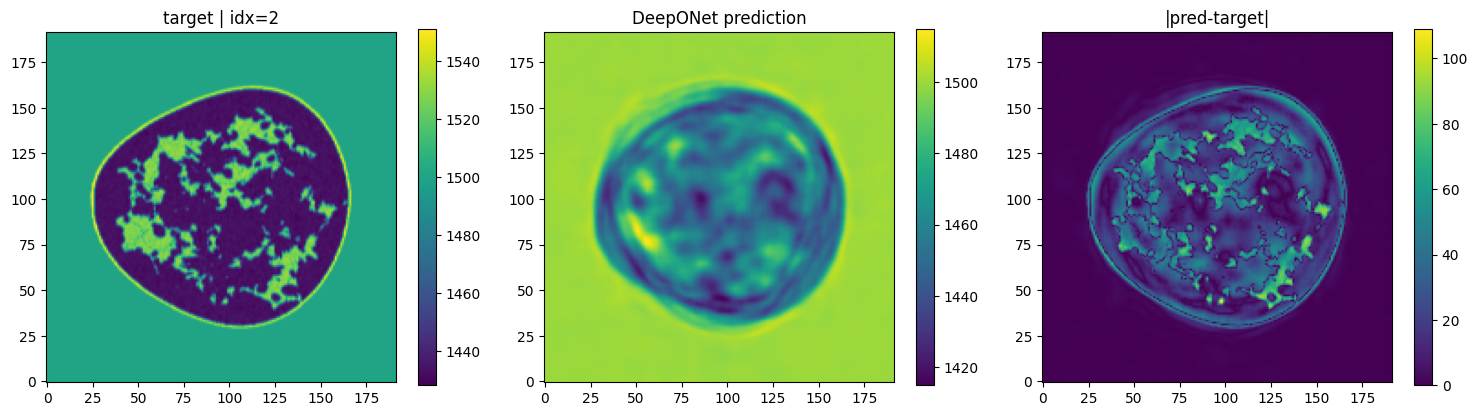

/workspace/usct_dataset_v2/test/sample_00002.npz


In [19]:
for idx in [0, 1, 2]:
    show_prediction(model, ds_test, idx, device, coords_device, stats["c_min"], stats["c_max"])

## 10. Сохранение итогов

In [20]:
with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "config": CFG,
            "stats": stats,
            "S": int(S),
            "R": int(R),
            "H": int(H),
            "W": int(W),
            "dx": [float(v) for v in dx],
            "freq_hz": float(freq_hz),
            "best_epoch": int(best_epoch),
            "best_val": float(best_val),
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

with open(RUN_DIR / "train_summary.json", "w", encoding="utf-8") as f:
    json.dump(train_summary, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "val_summary.json", "w", encoding="utf-8") as f:
    json.dump(val_summary, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "test_summary.json", "w", encoding="utf-8") as f:
    json.dump(test_summary, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "train_metrics.json", "w", encoding="utf-8") as f:
    json.dump(train_metrics, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "val_metrics.json", "w", encoding="utf-8") as f:
    json.dump(val_metrics, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, ensure_ascii=False, indent=2)

np.savez_compressed(
    RUN_DIR / "loss_history.npz",
    train_loss=np.array(train_history, dtype=np.float32),
    val_loss=np.array(val_history, dtype=np.float32),
)

print("saved to:", RUN_DIR)

saved to: /workspace/reference_points/deeponet_v1
